In [10]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os

#CONFIGURATION
DATA_PATH = r'D:\PJT2\CMAPSSData' 
PROCESSED_PATH = r'../../processed_data'
RUL_CAP = 125 
WINDOW_SIZE = 30 

# Columns
cols = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's{i}' for i in range(1, 22)]

### LOAD DATA 

In [4]:
print(f"Loading FD002 (Complex Conditions) from {DATA_PATH}...")
train_df = pd.read_csv(os.path.join(DATA_PATH, 'train_FD002.txt'), sep='\s+', header=None, names=cols)
test_df = pd.read_csv(os.path.join(DATA_PATH, 'test_FD002.txt'), sep='\s+', header=None, names=cols)
print(f"Train Shape: {train_df.shape}")

Loading FD002 (Complex Conditions) from D:\PJT2\CMAPSSData...
Train Shape: (53759, 26)


### CALCULATE RUL

In [5]:
def add_rul(df):
    max_cycle = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycle.columns = ['unit_number', 'max_cycle']
    df = df.merge(max_cycle, on='unit_number', how='left')
    df['RUL'] = df['max_cycle'] - df['time_in_cycles']
    df = df.drop(columns=['max_cycle'])
    df['RUL'] = df['RUL'].clip(upper=RUL_CAP)
    return df

train_df = add_rul(train_df)

### CLUSTER OPERATIONS

Clustering Operating Conditions (K-Means)...


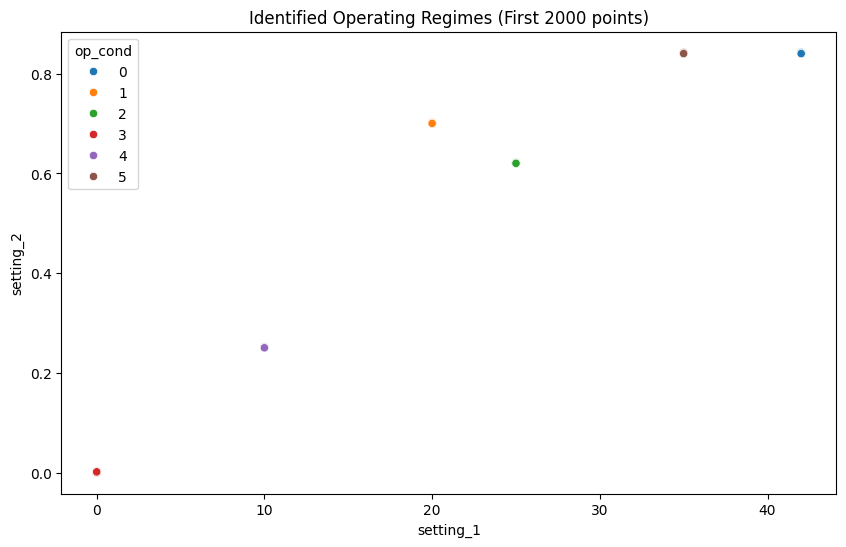

In [11]:
setting_cols = ['setting_1', 'setting_2', 'setting_3']

print("Clustering Operating Conditions (K-Means)...")
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

# Fit on TRAIN settings
train_df['op_cond'] = kmeans.fit_predict(train_df[setting_cols])
# Predict on TEST settings
test_df['op_cond'] = kmeans.predict(test_df[setting_cols])

# Visualize the Clusters (To prove they exist)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df.iloc[:2000], x='setting_1', y='setting_2', hue='op_cond', palette='tab10')
plt.title('Identified Operating Regimes (First 2000 points)')
plt.show()

### REGIME SPECIFIC NORMALIZATION

In [12]:
sensor_cols = [f's{i}' for i in range(1, 22)]
# In FD002, ALL sensors vary, so we keep them all usually, or drop constants if any.
# Let's check std deviation first.
stds = train_df[sensor_cols].std()
drop_sensors = stds[stds == 0].index.tolist()
print(f"Dropping Constant Sensors: {drop_sensors}")
valid_sensors = [s for s in sensor_cols if s not in drop_sensors]

print("Applying Z-Score Normalization per Operating Condition...")

def normalize_by_cluster(df, scaler_dict=None):
    df_norm = df.copy()
    if scaler_dict is None:
        scaler_dict = {}
        is_train = True
    else:
        is_train = False
        
    for cluster_id in range(6):
        # Get data for this cluster
        mask = df['op_cond'] == cluster_id
        if mask.sum() == 0: continue
        
        subset = df.loc[mask, valid_sensors]
        
        if is_train:
            # Create and fit a new scaler for this cluster
            scaler = StandardScaler()
            df_norm.loc[mask, valid_sensors] = scaler.fit_transform(subset)
            scaler_dict[cluster_id] = scaler
        else:
            # Use the saved scaler from training
            scaler = scaler_dict[cluster_id]
            df_norm.loc[mask, valid_sensors] = scaler.transform(subset)
            
    return df_norm, scaler_dict

train_norm, scalers = normalize_by_cluster(train_df)
test_norm, _ = normalize_by_cluster(test_df, scalers)

Dropping Constant Sensors: []
Applying Z-Score Normalization per Operating Condition...


C:\Users\91760\AppData\Local\Temp\ipykernel_16060\1481846613.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.75709823 -1.46698662 -0.75709823 ...  2.08245531  2.08245531
  2.08245531]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_norm.loc[mask, valid_sensors] = scaler.fit_transform(subset)
C:\Users\91760\AppData\Local\Temp\ipykernel_16060\1481846613.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.66267854 -0.75709823 -0.75709823 ...  0.66267854 -0.04720985
 -0.04720985]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_norm.loc[mask, valid_sensors] = scaler.transform(subset)


### SLIDING WINDOW

In [13]:
def gen_sequence(id_df, seq_length, seq_cols):
    data_matrix = id_df[seq_cols].values
    num_elements = data_matrix.shape[0]
    for start, stop in zip(range(0, num_elements-seq_length), range(seq_length, num_elements)):
        yield data_matrix[start:stop, :]

def gen_labels(id_df, seq_length, label):
    data_matrix = id_df[label].values
    return data_matrix[seq_length:]

X_train, y_train = [], []
for unit_id in train_norm['unit_number'].unique():
    unit_data = train_norm[train_norm['unit_number'] == unit_id]
    for seq in gen_sequence(unit_data, WINDOW_SIZE, valid_sensors):
        X_train.append(seq)
    for label in gen_labels(unit_data, WINDOW_SIZE, 'RUL'):
        y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)
print(f"X_train Shape: {X_train.shape}")

# Test Gen (Last Sequence Only)
X_test, y_test = [], []
true_ruls = pd.read_csv(os.path.join(DATA_PATH, 'RUL_FD002.txt'), header=None, names=['RUL'])

for unit_id in test_norm['unit_number'].unique():
    unit_data = test_norm[test_norm['unit_number'] == unit_id]
    if len(unit_data) >= WINDOW_SIZE:
        seq = unit_data[valid_sensors].values[-WINDOW_SIZE:]
        X_test.append(seq)
        y_test.append(true_ruls.iloc[unit_id-1].values[0])

X_test = np.array(X_test)
y_test = np.array(y_test)
print(f"X_test Shape: {X_test.shape}")

X_train Shape: (45959, 30, 21)
X_test Shape: (253, 30, 21)


### SAVING

In [14]:
if not os.path.exists(PROCESSED_PATH):
    os.makedirs(PROCESSED_PATH)

np.save(os.path.join(PROCESSED_PATH, 'X_train_FD002.npy'), X_train)
np.save(os.path.join(PROCESSED_PATH, 'y_train_FD002.npy'), y_train)
np.save(os.path.join(PROCESSED_PATH, 'X_test_FD002.npy'), X_test)
np.save(os.path.join(PROCESSED_PATH, 'y_test_FD002.npy'), y_test)